september 30th current data analysis
october 21th still useful
feb 26 this file has been reworked to mainly validate RAPL results


In [2]:
#use this to read rapl if it's PKG, DRAM and PSYS
SAMP_PATH = "/home/horizon/Downloads/experiments/DeathStarBench/results"

import os
import glob
import numpy as np
import pandas as pd
import struct

import os
import glob
import numpy as np
import pandas as pd

def read_rapl_binaries(SAMP_PATH):
    """
    Reads all binary files written by flush_to_file() in C:
        fwrite(ts_buf, sizeof(int64_t), BUF_SIZE, f);
        fwrite(e_buf, sizeof(float),   BUF_SIZE, f);

    Each file contains two contiguous arrays:
        - timestamps (int64 nanoseconds)
        - energy samples (float32 joules)
    Returns a pandas DataFrame with columns ['timestamp_ns', 'energy'].
    """

    # Match pattern like rapl_YYYYMMDD_HHMMSS_###.bin
    files = sorted(glob.glob(os.path.join(SAMP_PATH, "rapl_????????_??????_???.bin")))
    if not files:
        raise FileNotFoundError(f"No RAPL binary files found in {SAMP_PATH}")

    dfs = []
    for fname in files:
        with open(fname, "rb") as f:
            raw = f.read()

        # Each file contains BUF_SIZE timestamps (8 bytes each) + BUF_SIZE floats (4 bytes each) *3
        # So total length must be divisible by 20
        if len(raw) % 20 != 0:
            raise ValueError(f"File {fname} length {len(raw)} not multiple of 20 bytes")

        # Determine number of samples
        total_bytes = len(raw)
        n_samples = total_bytes // 20

        # Split manually
        ts_bytes = raw[:n_samples * 8]
        pkg_bytes = raw[n_samples * 8 : n_samples * 12]
        dram_bytes  =  raw[n_samples * 12 : n_samples * 16 ]
        psys_bytes  = raw[n_samples * 16:]

        timestamps = np.frombuffer(ts_bytes, dtype="<u8")  # little-endian int64
        energy_pkg     = np.frombuffer(pkg_bytes,  dtype="<f4")  # little-endian float32
        energy_dram     = np.frombuffer(dram_bytes,  dtype="<f4")  # little-endian float32
        energy_psys     = np.frombuffer(psys_bytes,  dtype="<f4")  # little-endian float32


        if len(timestamps) != len(energy_pkg):
            raise ValueError(f"Timestamp and energy count mismatch in {fname}")

        df = pd.DataFrame({
            "timestamp": timestamps,
            "energy_pkg" : energy_pkg,
            "energy_dram" : energy_dram,
            "energy_psys" : energy_psys,
        })
        df["energy"] = df["energy_pkg"]
        dfs.append(df)

    # Combine all
    df_all = pd.concat(dfs, ignore_index=True)
    return df_all

df_rapl = read_rapl_binaries(SAMP_PATH)
print(df_rapl.head(10))
print(df_rapl.shape)

       timestamp  energy_pkg  energy_dram  energy_psys    energy
0  5343375096274    0.082642          0.0          0.0  0.082642
1  5343375999427    0.000000          0.0          0.0  0.000000
2  5343377003930    0.041321          0.0          0.0  0.041321
3  5343378042220    0.038574          0.0          0.0  0.038574
4  5343379042186    0.047607          0.0          0.0  0.047607
5  5343380114345    0.032959          0.0          0.0  0.032959
6  5343381093248    0.045532          0.0          0.0  0.045532
7  5343382003006    0.000000          0.0          0.0  0.000000
8  5343382985047    0.056763          0.0          0.0  0.056763
9  5343384027421    0.045471          0.0          0.0  0.045471
(320000, 5)


In [ ]:
# prune outliers that look like 262143.968750, cause is unclear.
print(df_rapl.columns)
print(df_rapl["energy_pkg"].mean())
print(df_rapl["energy_pkg"].max())

df_outliers = df_rapl[df_rapl["energy_pkg"] > 200000]
print("outliers:")
print(df_outliers)

df_temp2 = df_rapl[df_rapl["energy_pkg"] < 200000]
print(f"pruned {len(df_rapl) - len(df_temp2)} outliers")
print(df_temp2["energy_pkg"].mean())
print(df_temp2.shape)

df_rapl=df_temp2

Index(['timestamp', 'energy_pkg', 'energy_dram', 'energy_psys', 'energy'], dtype='str')
4.9582577
262143.98
outliers:
            timestamp     energy_pkg  energy_dram  energy_psys         energy
10932   5354307964598  262143.968750          0.0          0.0  262143.968750
18186   5361562043948  262143.968750          0.0          0.0  262143.968750
119366  5462742004241  262143.984375          0.0          0.0  262143.984375
198455  5541830999659  262143.968750          0.0          0.0  262143.968750
205244  5548619998999  262143.984375          0.0          0.0  262143.984375
295109  5638484978590  262143.984375          0.0          0.0  262143.984375
pruned 6 outliers
0.043059427
(319994, 5)


In [16]:
print(df_rapl["timestamp"].max())
print(df_rapl["timestamp"].min())
print(df_rapl["timestamp"].mean())

df_outliers = df_rapl[df_rapl["timestamp"] == 0]
print("outliers:")
print(df_outliers)

df_temp3 = df_rapl[df_rapl["timestamp"] != 0]
print(f"pruned {len(df_rapl) - len(df_temp3)} outliers")
print(df_temp3["timestamp"].mean())
print(df_temp3.shape)
df_rapl = df_temp3


5663373957584
0
5503357830036.13
outliers:
      timestamp  energy_pkg  energy_dram  energy_psys  energy
3362          0         0.0          0.0          0.0     0.0
pruned 1 outliers
5503375028405.565
(319993, 5)


In [ ]:
duplicated_rows_df = df_rapl[df_rapl.duplicated(subset = ["timestamp"], keep = False)]
duplicated_rows_df = duplicated_rows_df.sort_values(by="timestamp")
print("Found these rows duplicated observations.")
print(duplicated_rows_df)
df_temp4 = df_rapl.drop_duplicates(subset=["timestamp"], keep= 'first')
print(f"dropping {len(df_rapl) - len(df_temp4)} duplicated rows")
df_rapl = df_temp4

            timestamp  energy_pkg  energy_dram  energy_psys    energy
934     5344308956712    0.011475          0.0          0.0  0.011475
10934   5344308956712    0.011475          0.0          0.0  0.011475
8187    5351561959477    0.027771          0.0          0.0  0.027771
18187   5351561959477    0.027771          0.0          0.0  0.027771
65362   5408736995480    0.107239          0.0          0.0  0.107239
75362   5408736995480    0.107239          0.0          0.0  0.107239
109367  5452742006288    0.139587          0.0          0.0  0.139587
119367  5452742006288    0.139587          0.0          0.0  0.139587
188456  5531830983889    0.032166          0.0          0.0  0.032166
198456  5531830983889    0.032166          0.0          0.0  0.032166
195245  5538620012013    0.010254          0.0          0.0  0.010254
205245  5538620012013    0.010254          0.0          0.0  0.010254
202690  5546064996174    0.000000          0.0          0.0  0.000000
212690  554606499617

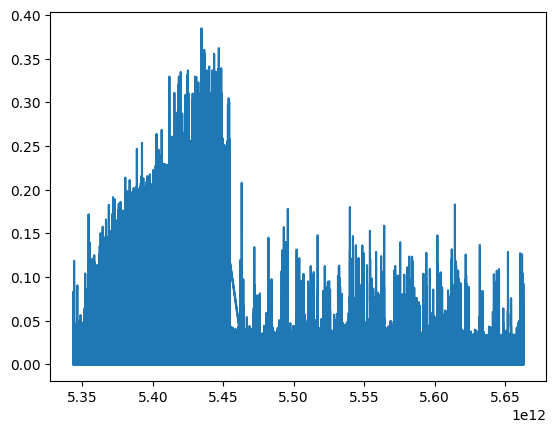

In [17]:
import matplotlib.pyplot as plt
plt.plot(df_rapl["timestamp"].values,df_rapl["energy_pkg"].values)
plt.show()

In [ ]:
rollovers = find_rollovers(df_rapl)
print(df_rapl.shape)
df_rapl = drop_around_overflows(df_rapl, rollovers)
print(df_rapl.shape)


In [4]:
def compute_power_from_energy(df: pd.DataFrame,
                              time_col: str = "timestamp",
                              energy_col: str = "energy") -> pd.DataFrame:
    """
    Compute instantaneous power (Watts) from cumulative energy (Joules)
    using timestamp differences in nanoseconds.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing 'timestamp' (ns) and 'energy' (Joule).
    time_col : str, default 'timestamp'
        Column name for timestamp (in nanoseconds).
    energy_col : str, default 'energy'
        Column name for cumulative energy (in Joules).

    Returns
    -------
    pd.DataFrame
        Copy of df with a new 'power' column (float32, in Watts).
    """
    result = df.copy()

    # Compute differences
    dE = result[energy_col]        # ΔEnergy (J)
    dT_ns = result[time_col].diff()        # ΔTime (ns)
    
    # Avoid divide-by-zero or negative intervals
    dT_ns = dT_ns.replace(0, np.nan)

    # Convert ns → seconds and compute power (Watts = J / s)
    result["power"] = (dE / (dT_ns * 1e-9)).astype("float32")

    return result

df_rapl_watt = compute_power_from_energy(df_rapl).dropna()
df_rapl_watt["dram_rapl"] = compute_power_from_energy(df_rapl, energy_col="energy_dram").dropna()["power"]
print(df_rapl_watt.shape)
print(df_rapl_watt.head(5))

(29999, 7)
       timestamp  energy_pkg  energy_dram  energy_psys    energy      power  \
1  2003906221236    0.050476          0.0          0.0  0.050476  49.011654   
2  2003907207960    0.050720          0.0          0.0  0.050720  51.402637   
3  2003908212361    0.000000          0.0          0.0  0.000000   0.000000   
4  2003909207368    0.045654          0.0          0.0  0.045654  45.883392   
5  2003910230809    0.041321          0.0          0.0  0.041321  40.374386   

   dram_rapl  
1        0.0  
2        0.0  
3        0.0  
4        0.0  
5        0.0  


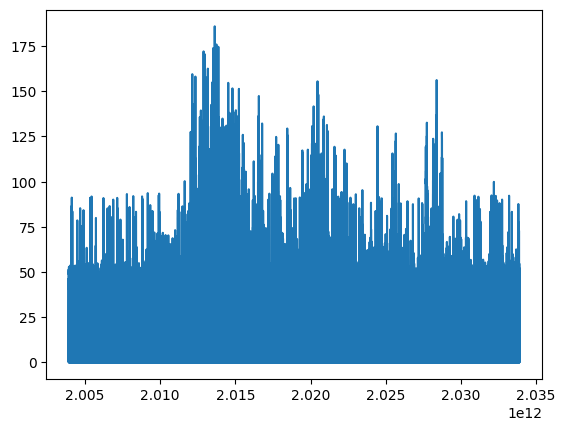

In [6]:
import matplotlib.pyplot as plt
plt.plot(df_rapl_watt["timestamp"].values,df_rapl_watt["power"].values)
plt.show()

Apparently, in extrmeely rare circumstances, rapl time can be 0. it is entirely unclear why this happens, but it's rare and only affects 1 in 100,000 observations. 

In [8]:
#df_rapl_watt = df_rapl_watt.iloc[2:]
print(df_rapl_watt.head())

count_zero = (df_rapl_watt["timestamp"]==0).sum()
print(count_zero)
df_rapl_watt = df_rapl_watt[df_rapl_watt["timestamp"] != 0]
count_zero = (df_rapl_watt["timestamp"] ==0).sum()
print(count_zero)



      timestamp  energy_pkg  energy_dram  energy_psys    energy      power  \
1  281347222072    0.015503          0.0          0.0  0.015503  18.286415   
2  281348254476    0.013611          0.0          0.0  0.013611  13.183638   
3  281349230078    0.000000          0.0          0.0  0.000000   0.000000   
4  281350249237    0.012329          0.0          0.0  0.012329  12.097329   
5  281351321157    0.011169          0.0          0.0  0.011169  10.420026   

   dram_rapl  
1        0.0  
2        0.0  
3        0.0  
4        0.0  
5        0.0  
1
0


In [7]:
#plot_timestamp_distribution_parallel
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

def plot_timestamp_distribution_parallel(df1, df2, time_col="timestamp", label1="df1", label2="df2"):
    """
    Plot two timestamp distributions in parallel (non-overlapping) rows.
    X-axis: timestamp values
    Y-axis: fixed levels to separate datasets visually.
    """

    plt.figure(figsize=(10, 4))

    # fixed y-levels for visual separation
    y1 = [1] * len(df1)
    y2 = [0] * len(df2)

    plt.scatter(df1[time_col], y1, label=label1, alpha=0.7, s=10)
    plt.scatter(df2[time_col], y2, label=label2, alpha=0.7, s=10)

    plt.yticks([0, 1], [label2, label1])
    plt.xlabel("Timestamp")
    plt.ylabel("Dataset")
    plt.title("Parallel Timestamp Distribution")
    plt.grid(True, axis="x", linestyle="--", alpha=0.5)
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

plot_timestamp_distribution_parallel(corrected_df, df_rapl_watt)

NameError: name 'corrected_df' is not defined

In [26]:
print(df_rapl_watt.head(5))
df_rapl_watt["timestamp"] = df_rapl_watt["timestamp"] - 8642644546100
print(corrected_df.head(5))

       timestamp  energy_pkg  energy_dram  energy_psys    energy      power  \
1  8642644546123    0.018127          0.0          0.0  0.018127  23.965418   
2  8642645604282    0.000000          0.0          0.0  0.000000   0.000000   
3  8642646611901    0.017395          0.0          0.0  0.017395  17.263489   
4  8642647508125    0.017212          0.0          0.0  0.017212  19.204924   
5  8642648627550    0.016418          0.0          0.0  0.016418  14.666866   

   dram_rapl  
1        0.0  
2        0.0  
3        0.0  
4        0.0  
5        0.0  
    timestamp         A         B         C         D         H         I  \
0  3142593708  1.738695  0.377480  1.647185  0.411796  2.413584  0.732082   
1  3143189750  1.738695  0.354602  1.647185  0.411796  2.356390  0.754960   
2  3143785875  1.784450  0.354602  1.647185  0.411796  2.322073  0.732082   
3  3144382333  1.944593  0.377480  1.784450  0.434674  2.470778  0.732082   
4  3144978500  1.738695  0.354602  1.647185  0.411

In [9]:
# plothelper def plot_columns(df, columns, x_col=None, title=None, xlabel=None, ylabel=None, figsize=(10, 5), style='-', markersize=2, alpha=0.9, legend=True):
import matplotlib.pyplot as plt

def plot_columns(df, columns, x_col=None, title=None, xlabel=None, ylabel=None,
                 figsize=(10, 5), style='-', markersize=2, alpha=0.9, legend=True):
    """
    Plot one or more DataFrame columns using matplotlib.

    Parameters
    ----------
    df : pd.DataFrame
        The DataFrame containing the data.
    columns : list of str
        List of column names to plot.
    x_col : str, optional
        Column name to use as the x-axis. If None, use the DataFrame index.
    title : str, optional
        Plot title.
    xlabel, ylabel : str, optional
        Axis labels.
    figsize : tuple, optional
        Figure size.
    style : str, optional
        Line style (default: '-').
    markersize : int, optional
        Marker size (default: 2).
    alpha : float, optional
        Line transparency (default: 0.9).
    legend : bool, optional
        Whether to show a legend.

    Returns
    -------
    matplotlib.axes.Axes
        The plot’s axes object.
    """
    plt.figure(figsize=figsize)

    # Choose x-axis
    x = df[x_col] if x_col else df.index

    for col in columns:
        if col not in df.columns:
            print(f"⚠️ Column '{col}' not found, skipping.")
            continue
        plt.plot(x, df[col], style, label=col, markersize=markersize, alpha=alpha)

    plt.title(title or "Data Plot")
    plt.xlabel(xlabel or (x_col if x_col else "Index"))
    plt.ylabel(ylabel or "Value")

    if legend:
        plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return

Index(['timestamp', 'energy_pkg', 'energy_dram', 'energy_psys', 'energy',
       'power', 'dram_rapl'],
      dtype='str')


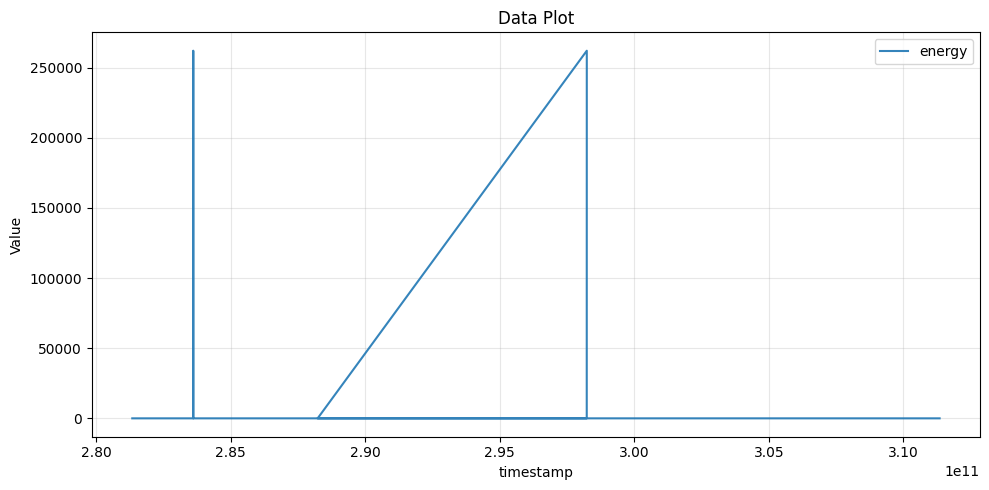

In [10]:
# df_rapl_watt["timestamp_s"] = df_rapl_watt["timestamp"] / 1000_000_000
print(df_rapl_watt.columns)
plot_columns(df=df_rapl_watt, columns=["energy"], x_col="timestamp")

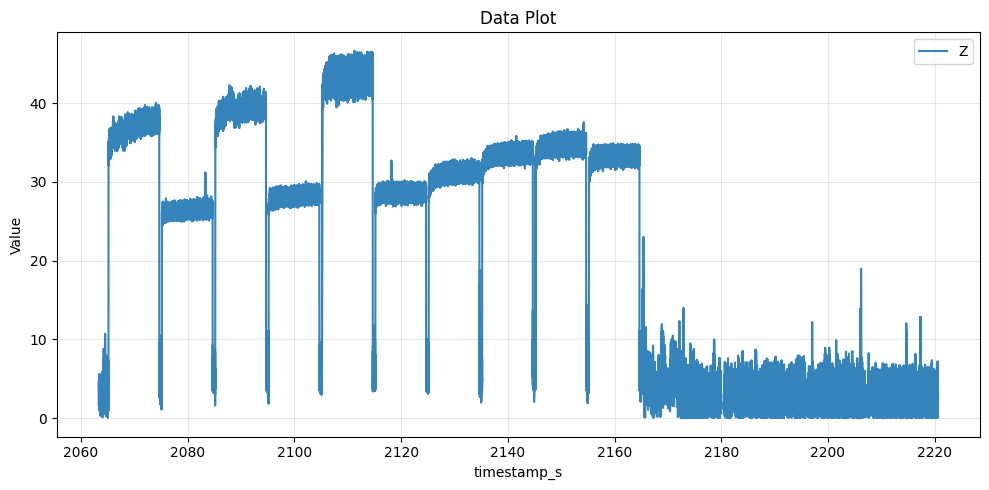

In [10]:
corrected_df["timestamp_s"] = corrected_df["timestamp"] / 1000_000_000
plot_columns(df=corrected_df, columns=["Z"], x_col="timestamp_s")

shuffle the workload later to remove influence of time 
P core and E core 
temperature 
run this workload, stop and run again without allowing the cpu to cool 
the second, third run 

1000176.1540483321
0          NaN
1     948541.0
2    1039960.0
3     984884.0
4    1016418.0
Name: timestamp, dtype: float64
1000176.1540483321
   index       timestamp  energy_pkg  energy_dram  energy_psys    energy  \
2      3  17352801291663    0.008301     0.002075          0.0  0.008301   
4      5  17352803292965    0.006409     0.001282          0.0  0.006409   
5      6  17352804299661    0.005554     0.001404          0.0  0.005554   
7      8  17352806310943    0.008789     0.002319          0.0  0.008789   
9     10  17352808342128    0.008850     0.002136          0.0  0.008850   

      power    ts_diff  
2  7.981827  1039960.0  
4  6.305173  1016418.0  
5  5.517256  1006696.0  
7  8.430570  1042523.0  
9  8.366244  1057834.0  


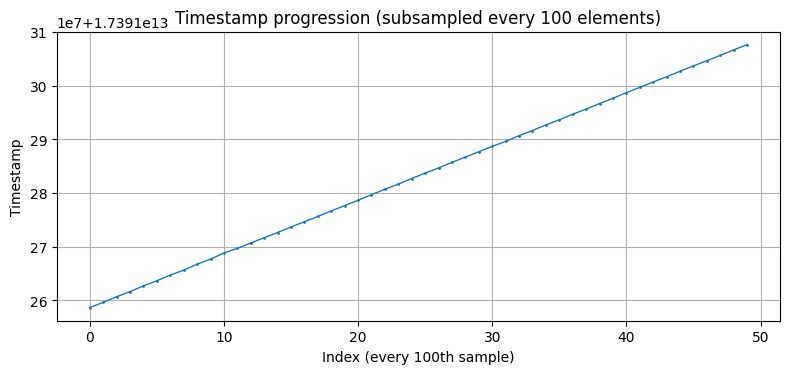

In [8]:
print(df_rapl_watt["timestamp"].diff().dropna().mean())

df_time_explore = df_rapl_watt.reset_index(names="index")
diff_mean = df_time_explore["timestamp"].diff().dropna().mean()
print(df_time_explore["timestamp"].diff().head())
print(diff_mean)
df_time_explore["ts_diff"] = df_time_explore["timestamp"].diff()
outliers = df_time_explore[df_time_explore["ts_diff"] > diff_mean]
print(outliers.head())

ts_sub_1 = df_rapl_watt["timestamp"].iloc[38450:38500].reset_index(drop=True)
# Plot timestamp vs index
plt.figure(figsize=(8, 4))
plt.plot(ts_sub_1.index, ts_sub_1, marker='o', linestyle='-', linewidth=1, markersize=1)

plt.xlabel("Index (every 100th sample)")
plt.ylabel("Timestamp")
plt.title("Timestamp progression (subsampled every 100 elements)")
plt.grid(True)
plt.tight_layout()
plt.show()



In [5]:
import pandas as pd
import numpy as np

def merge_by_bracketing_average(df1, df2, time_col="timestamp", t=500_000, suffix="_2"):
    """
    Bracket-merge df1 with df2 using integer timestamp arithmetic only.
    """

    # Sort
    df1 = df1.sort_values(time_col).reset_index(drop=True)
    df2 = df2.sort_values(time_col).reset_index(drop=True)

    t1 = df1[time_col].to_numpy(np.int64)
    t2 = df2[time_col].to_numpy(np.int64)

    # Get nearest right index in df2
    idx_right = np.searchsorted(t2, t1, side="left")
    idx_left = idx_right - 1

    # Clip to valid range inside df2
    idx_left = np.clip(idx_left, 0, len(t2) - 1)
    idx_right = np.clip(idx_right, 0, len(t2) - 1)

    # Gather timestamps
    t_left  = t2[idx_left]
    t_right = t2[idx_right]

    # Integer differences
    diff_left  = np.abs(t1 - t_left)
    diff_right = np.abs(t1 - t_right)

    # Require that left < t1 < right AND both within tolerance
    valid = (
        (diff_left <= t) &
        (diff_right <= t) &
        (t_left <= t1) &
        (t_right >= t1) &
        (idx_left != idx_right)
    )

    if not valid.any():
        return df1.iloc[0:0]   # empty

    # Filter indices
    df1_valid = df1[valid].reset_index(drop=True)
    left_idx  = idx_left[valid]
    right_idx = idx_right[valid]

    left_df2  = df2.iloc[left_idx].reset_index(drop=True)
    right_df2 = df2.iloc[right_idx].reset_index(drop=True)

    # Integer midpoint timestamp
    # (safe: stays int64)
    merged_time = (left_df2[time_col].to_numpy(np.int64)
                   + right_df2[time_col].to_numpy(np.int64)) // 2

    # Average only numeric columns, integer arithmetic
    df2_avg = left_df2.copy()
    numeric_cols = df2_avg.select_dtypes(include=[np.number]).columns

    for c in numeric_cols:
        df2_avg[c] = (left_df2[c].to_numpy(np.int64)
                      + right_df2[c].to_numpy(np.int64)) // 2

    # Write midpoint timestamp to separate column
    df2_avg[time_col + suffix] = merged_time

    # Merge side-by-side
    merged = pd.concat(
        [df1_valid.reset_index(drop=True),
         df2_avg.add_suffix(suffix)],
        axis=1
    )

    # Integer difference
    merged["timestamp_diff"] = (
        merged[time_col + suffix] - merged[time_col]
    ).astype(np.int64)

    return merged

df_rapl_watt["timestamp_1"] = df_rapl_watt["timestamp"]
corrected_df["timestamp_2"] = corrected_df["timestamp"]

print(df_rapl_watt.shape)
rapl_teensy_merged = merge_by_bracketing_average(df1=df_rapl_watt, df2=corrected_df, time_col="timestamp", t=500000, suffix="_2")
print(rapl_teensy_merged.shape)

(179999, 8)
(105973, 27)


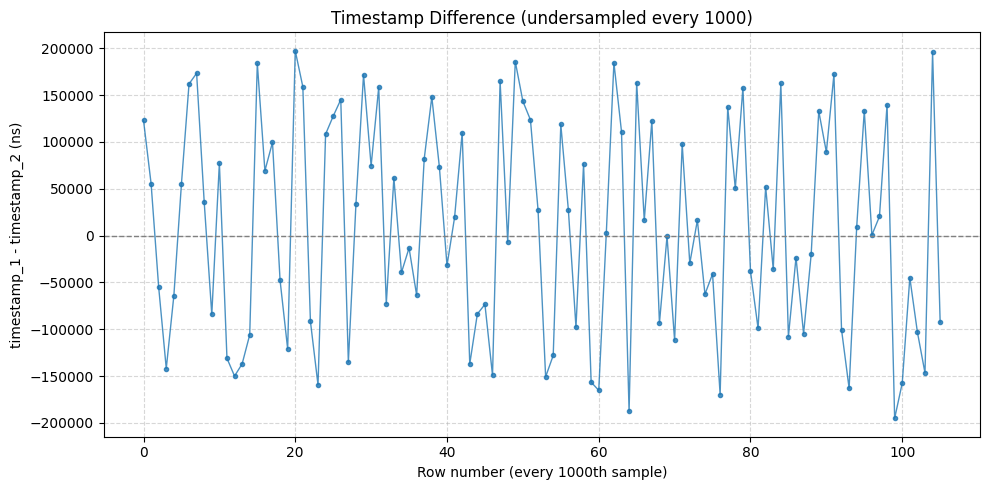

In [10]:
import matplotlib.pyplot as plt

def plot_timestamp_difference_undersampled(
    merged_df, ts1_col="timestamp_1", ts2_col="timestamp_2", step=1000, title=None
):
    """
    Plot undersampled difference between two timestamp columns,
    using row number as the X-axis.

    Parameters
    ----------
    merged_df : pd.DataFrame
        DataFrame containing both timestamp columns.
    ts1_col : str
        Column name for the left (master) timestamp.
    ts2_col : str
        Column name for the right (aligned) timestamp.
    step : int, default 100
        Sampling step size (take every nth row).
    title : str, optional
        Custom plot title.
    """

    # undersample
    df_sub = merged_df.iloc[0:345000].iloc[::step].copy()

    # compute difference
    diff = df_sub[ts1_col] - df_sub[ts2_col]
    diff = diff.replace([np.inf, -np.inf], np.nan)

    # x-axis as row number
    x = np.arange(len(df_sub))

    plt.figure(figsize=(10, 5))
    plt.plot(x, diff, marker=".", linestyle="-", linewidth=1, alpha=0.8)
    plt.axhline(0, color="gray", linestyle="--", linewidth=1)

    plt.xlabel(f"Row number (every {step}th sample)")
    plt.ylabel(f"{ts1_col} - {ts2_col} (ns)")
    plt.title(title or f"Timestamp Difference (undersampled every {step})")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_timestamp_difference_undersampled(rapl_teensy_merged, ts1_col="timestamp_1", ts2_col="timestamp_2")

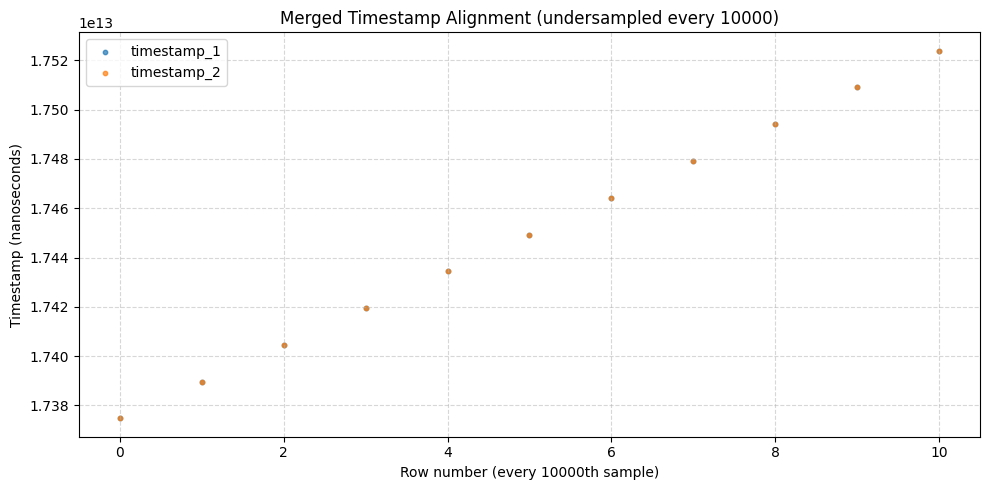

In [11]:
import matplotlib.pyplot as plt
import numpy as np

def plot_merged_timestamps_undersampled(
    merged_df, ts1_col="timestamp_1", ts2_col="timestamp_2", step=10000, title=None
):
    """
    Plot both merged timestamp columns vs. row number, undersampled, using dots instead of lines.

    Parameters
    ----------
    merged_df : pd.DataFrame
        DataFrame after merge_asof() containing both timestamp columns.
    ts1_col : str
        Column name for the left (master) timestamp.
    ts2_col : str
        Column name for the right (aligned) timestamp.
    step : int, default 100
        Sampling step size (take every nth row).
    title : str, optional
        Optional title for the plot.
    """

    # undersample
    df_sub = merged_df.iloc[::step].copy()
    x = np.arange(len(df_sub))

    plt.figure(figsize=(10, 5))
    plt.scatter(x, df_sub[ts1_col], label=ts1_col, s=10, alpha=0.7)
    plt.scatter(x, df_sub[ts2_col], label=ts2_col, s=10, alpha=0.7)

    plt.xlabel(f"Row number (every {step}th sample)")
    plt.ylabel("Timestamp (nanoseconds)")
    plt.title(title or f"Merged Timestamp Alignment (undersampled every {step})")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_merged_timestamps_undersampled(rapl_teensy_merged, ts1_col="timestamp_1", ts2_col="timestamp_2")

In [6]:
rapl_teensy_merged["cpu_total"] = (rapl_teensy_merged["Y_2"].astype("float32") + rapl_teensy_merged["Z_2"].astype("float32")).astype("float32")
rapl_teensy_merged["abs_total"] = (rapl_teensy_merged["A_2"]+rapl_teensy_merged["B_2"]+rapl_teensy_merged["C_2"]+rapl_teensy_merged["D_2"]+rapl_teensy_merged["H_2"]+rapl_teensy_merged["I_2"]+rapl_teensy_merged["J_2"]+rapl_teensy_merged["K_2"]+rapl_teensy_merged["Y_2"]+rapl_teensy_merged["Z_2"]+rapl_teensy_merged["O_2"]+rapl_teensy_merged["P_2"]+rapl_teensy_merged["Q_2"]+rapl_teensy_merged["R_2"]+rapl_teensy_merged["U_2"]+rapl_teensy_merged["V_2"])
rapl_teensy_merged.head(3)


,timestamp,energy_pkg,energy_dram,energy_psys,energy,power,dram_rapl,timestamp_1,timestamp_2,A_2,...,O_2,P_2,Q_2,R_2,U_2,V_2,timestamp_2_2,timestamp_diff,cpu_total,abs_total
0,17374779970977,0.004028,0.000854,0.0,0.004028,4.043727,0.857760,17374779970977,17374779847710,0,...,0,1,1,1,5,1,17374779847710,-123267,7.0,18
1,17374780971250,0.004395,0.001099,0.0,0.004395,4.393332,1.098333,17374780971250,17374781042293,1,...,0,1,1,1,5,1,17374781042293,71043,8.0,20
2,17374782966323,0.003601,0.000916,0.0,0.003601,3.561319,0.905420,17374782966323,17374782834231,1,...,0,1,1,1,4,1,17374782834231,-132092,8.0,19


In [10]:
rapl_teensy_merged["timestamp_s"] = rapl_teensy_merged["timestamp"] / 1000_000_000

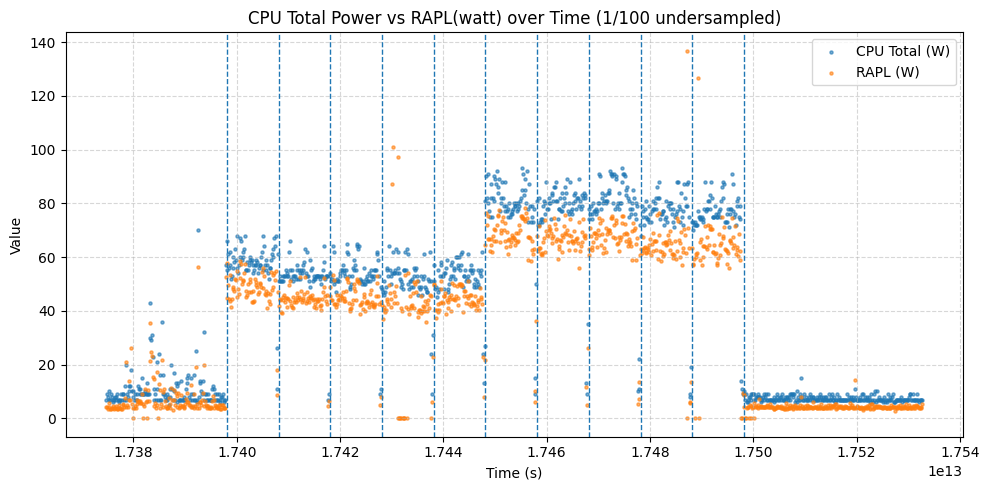

In [7]:
import matplotlib.pyplot as plt

def plot_cpu_vs_energy(df, time_col="timestamp_s", cpu_col="cpu_total", energy_col="power", sample_factor=1000, segments=[]):
    """
    Plot CPU total power and energy over time with small points and different colors,
    undersampling for performance.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing timestamp, cpu_total, and energy columns.
    time_col : str
        Name of the timestamp column (x-axis).
    cpu_col : str
        Name of the CPU total column (y-axis, one color).
    energy_col : str
        Name of the energy column (y-axis, another color).
    sample_factor : int, default 100
        Plot every Nth row for undersampling.
    """
    # Undersample
    df_sub = df.iloc[::sample_factor, :]

    plt.figure(figsize=(10, 5))
    plt.scatter(df_sub[time_col], df_sub[cpu_col], s=5, color='tab:blue', alpha=0.6, label="CPU Total (W)")
    plt.scatter(df_sub[time_col], df_sub[energy_col], s=5, color='tab:orange', alpha=0.6, label="RAPL (W)")

    plt.xlabel("Time (s)")
    plt.ylabel("Value")
    plt.title(f"CPU Total Power vs RAPL(watt) over Time (1/{sample_factor} undersampled)")
    plt.legend()

    for xc in segments:
        plt.axvline(x=xc, linestyle="--", linewidth=1)

    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


segments = [17398106102790, 17408115632950, 17418125344082, 17428134473623, 17438142474785, 17448150626666, 17458160825127, 17468168994269, 17478177946304,17488185946880, 17498193747238]

plot_cpu_vs_energy(rapl_teensy_merged, sample_factor=100, time_col="timestamp", segments=segments)

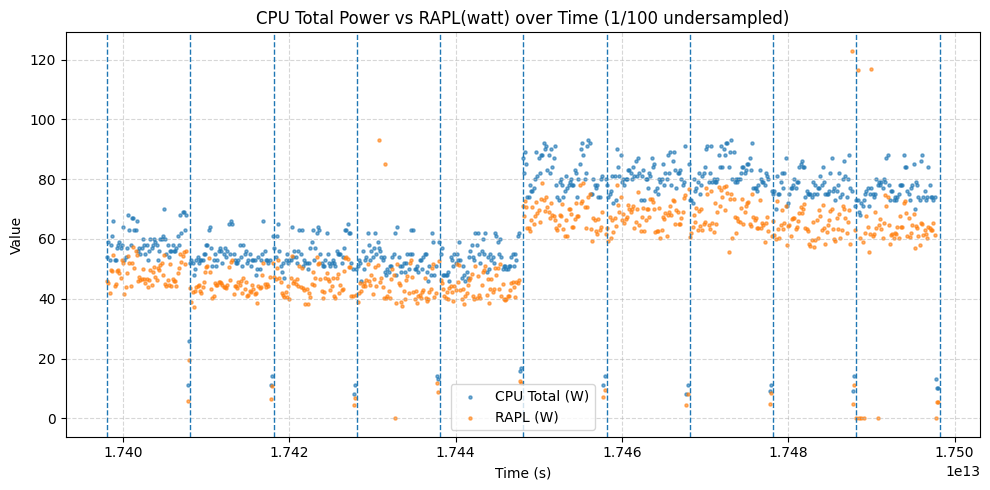

In [13]:
# running this cell will clip the main data to only workload. if any other analysis is desired, reset notebook
rapl_teensy_merged = rapl_teensy_merged[(rapl_teensy_merged["timestamp"] >= 17398106102790) & (rapl_teensy_merged["timestamp"] <= 17498193747238)]
plot_cpu_vs_energy(rapl_teensy_merged, sample_factor=100, time_col="timestamp", segments=segments)


7
113
(364, 867)
349
108
0.875
0.6
15.200000000000001
5.5


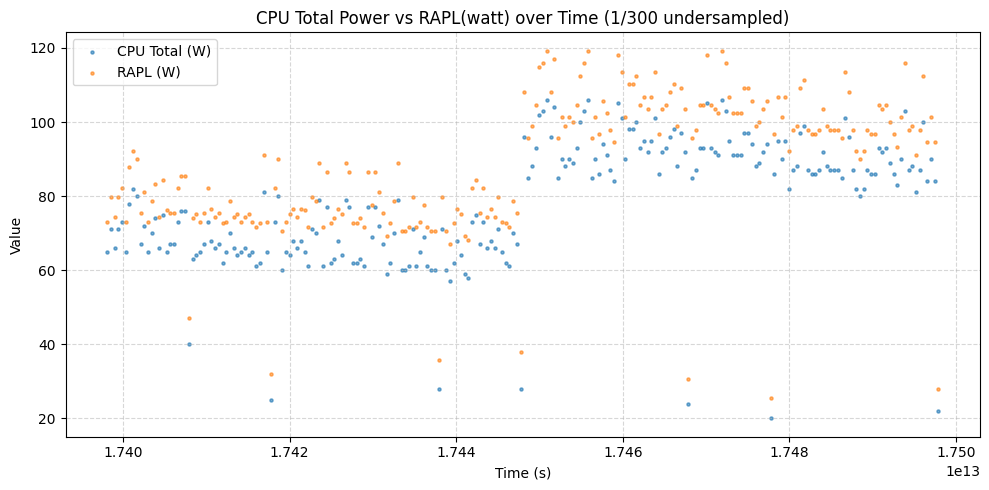

In [15]:
# this section calculates power coverage. 
# for each measurement, minor and major rail power split is used to derive the efficiency factor, which is then used to calculate the PSU efficiency cost
minor_rails = ["I_2", "J_2", "A_2", "B_2", "C_2", "D_2", "V_2"]
major_rails = ["H_2", "K_2", "O_2", "P_2", "Q_2", "R_2", "U_2", "Y_2", "Z_2"]
rapl_teensy_merged["minor_rails_total"] = rapl_teensy_merged[minor_rails].sum(axis=1)
rapl_teensy_merged["major_rails_total"] = rapl_teensy_merged[major_rails].sum(axis=1)

print(rapl_teensy_merged["minor_rails_total"].max())
print(rapl_teensy_merged["major_rails_total"].max())

#load modifiers 
# something to note about images: the top is actually Y = 0, so images are all backwards in terms of the Y value. Do not forget this during processing.
modifier_path = "C:/Users/andyh/Downloads/serialreceive/adjustmentFactor/modifier.npy"
modifier_array = np.load(modifier_path)
MAX_X_VAL = 900
MAX_Y_VAL = 160
print(modifier_array.shape)
max_x = modifier_array.shape[1]
max_y = modifier_array.shape[0]


coverage_preprocessing = pd.DataFrame()
coverage_preprocessing["minor_rails_y"] = max_y - (rapl_teensy_merged["minor_rails_total"] / MAX_Y_VAL * max_y).astype(int) # again this is because in images Y = 0 is the top
coverage_preprocessing["major_rails_x"] = (rapl_teensy_merged["major_rails_total"] / MAX_X_VAL * max_x).astype(int)
print(coverage_preprocessing["minor_rails_y"].min())
print(coverage_preprocessing["major_rails_x"].max())

ix = coverage_preprocessing["major_rails_x"].to_numpy()
iy = coverage_preprocessing["minor_rails_y"].to_numpy()

rapl_teensy_merged["psu_multiplier"] = modifier_array[iy, ix]
print(rapl_teensy_merged["psu_multiplier"].max())
print(rapl_teensy_merged["psu_multiplier"].min())

rapl_teensy_merged["psu_watt"] = rapl_teensy_merged["abs_total"] * (1 - rapl_teensy_merged["psu_multiplier"])
rapl_teensy_merged["psu_adjusted_total"] = rapl_teensy_merged["abs_total"] + rapl_teensy_merged["psu_watt"]
print(rapl_teensy_merged["psu_watt"].max())
print(rapl_teensy_merged["psu_watt"].min())

temp_df_for_display = pd.DataFrame()
temp_df_for_display["adjusted_total"] = rapl_teensy_merged["abs_total"] + rapl_teensy_merged["psu_watt"]
temp_df_for_display["abs_total"] = rapl_teensy_merged["abs_total"]
temp_df_for_display["timestamp"] = rapl_teensy_merged["timestamp"]
plot_cpu_vs_energy(temp_df_for_display, time_col="timestamp",cpu_col="abs_total", energy_col="adjusted_total", sample_factor=300)





In [16]:
def trapezoid (df, col= "cpu_total"): 

    # time differences (seconds)
    dt = df["timestamp"].diff() / 1e9
    df["timestamp_s"] = df["timestamp"] / 1e9

    # trapezoid: average power * time
    #energy_joules = ((df[col][:-1].values + df[col][1:].values) / 2 * dt[1:].values).sum() #naive trapezoid 
    energy_joules = np.trapz(df[col].values, x=df["timestamp_s"].values) #npz trapezoid

    # convert to kWh
    energy_kwh = energy_joules / 3_600_000

    print(col)
    print("Energy (J):", energy_joules)
    print("Energy (kWh):", energy_kwh)
    return energy_kwh

In [24]:
rapl_teensy_merged['NIC'] = rapl_teensy_merged['I_2']
rapl_teensy_merged['DRAM'] = rapl_teensy_merged['P_2'] + rapl_teensy_merged['Q_2'] + rapl_teensy_merged['R_2'] + rapl_teensy_merged['A_2'] + rapl_teensy_merged['C_2']
# rapl_teensy_merged['cpu_total']
rapl_teensy_merged['DISK'] = rapl_teensy_merged['U_2'] + rapl_teensy_merged['V_2']

total_j = trapezoid(rapl_teensy_merged, col='psu_adjusted_total')

print(trapezoid(rapl_teensy_merged, col='NIC'))
print(trapezoid(rapl_teensy_merged, col='DRAM'))
print(trapezoid(rapl_teensy_merged, col='cpu_total'))
print(trapezoid(rapl_teensy_merged, col='DISK'))
print(trapezoid(rapl_teensy_merged, col='abs_total'))

mainboard_ratio = 1 - trapezoid(rapl_teensy_merged, col='psu_watt')/total_j - trapezoid(rapl_teensy_merged, col='cpu_total')/total_j - trapezoid(rapl_teensy_merged, col='DRAM')/total_j - trapezoid(rapl_teensy_merged, col='DISK')/total_j - trapezoid(rapl_teensy_merged, col='NIC')/total_j

rapl_unaccounted_ratio = 1 - trapezoid(rapl_teensy_merged, col='cpu_total')/total_j - trapezoid(rapl_teensy_merged, col='DRAM')/total_j

data_sensor = [
    ("CPU",   "#3E7695", trapezoid(rapl_teensy_merged, col='cpu_total')/total_j),
    ("DRAM",   "#E5D35E", trapezoid(rapl_teensy_merged, col='DRAM')/total_j),
    ("DISK", "#DD8A52", trapezoid(rapl_teensy_merged, col='DISK')/total_j),
    ("NIC",  "#C44E52", trapezoid(rapl_teensy_merged, col='NIC')/total_j),
    ("Mainboard","#255430", mainboard_ratio ),
    ("PSU", "#32CD32", trapezoid(rapl_teensy_merged, col='psu_watt')/total_j )
]

data_rapl = [
    ("RAPL_PKG",   "#3E7695", trapezoid(rapl_teensy_merged, col='power')/total_j),
    ("RAPL_PKG underestimation",   "#696969", trapezoid(rapl_teensy_merged, col='cpu_total')/total_j - trapezoid(rapl_teensy_merged, col='power')/total_j),
    ("RAPL_DRAM",   "#E5D35E", trapezoid(rapl_teensy_merged, col='dram_rapl')/total_j),
    ("RAPL_DRAM underestimation",   "#a1a1a1", trapezoid(rapl_teensy_merged, col='DRAM')/total_j - trapezoid(rapl_teensy_merged, col='dram_rapl')/total_j ),
    ("DISK", "#969696", trapezoid(rapl_teensy_merged, col='DISK')/total_j),
    ("NIC",  "#8a8a8a", trapezoid(rapl_teensy_merged, col='NIC')/total_j),
    ("Mainboard","#3d3d3d", mainboard_ratio ),
    ("PSU", "#808080", trapezoid(rapl_teensy_merged, col='psu_watt')/total_j )
]

data_rapl_legend = [
    ("RAPL_PKG",   "#3E7695", trapezoid(rapl_teensy_merged, col='power')/total_j),
    ("RAPL_DRAM",   "#E5D35E", trapezoid(rapl_teensy_merged, col='dram_rapl')/total_j),
    ("Unaccounted", "#696969", rapl_unaccounted_ratio)
]

psu_adjusted_total
Energy (J): 8857.087752018577
Energy (kWh): 0.0024603021533384935
NIC
Energy (J): 206.0785984385093
Energy (kWh): 5.7244055121808135e-05
5.7244055121808135e-05
DRAM
Energy (J): 522.4240952452928
Energy (kWh): 0.00014511780423480356
0.00014511780423480356
cpu_total
Energy (J): 6545.918272739187
Energy (kWh): 0.0018183106313164408
0.0018183106313164408
DISK
Energy (J): 533.2034459710867
Energy (kWh): 0.00014811206832530187
0.00014811206832530187
abs_total
Energy (J): 7807.629395397076
Energy (kWh): 0.0021687859431658543
0.0021687859431658543
psu_watt
Energy (J): 1049.4583566215015
Energy (kWh): 0.0002915162101726393
cpu_total
Energy (J): 6545.918272739187
Energy (kWh): 0.0018183106313164408
DRAM
Energy (J): 522.4240952452928
Energy (kWh): 0.00014511780423480356
DISK
Energy (J): 533.2034459710867
Energy (kWh): 0.00014811206832530187
NIC
Energy (J): 206.0785984385093
Energy (kWh): 5.7244055121808135e-05
cpu_total
Energy (J): 6545.918272739187
Energy (kWh): 0.001818310631

C:\Users\andyh\AppData\Local\Temp\ipykernel_14992\1457331785.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy_joules = np.trapz(df[col].values, x=df["timestamp_s"].values) #npz trapezoid


In [21]:
import matplotlib.pyplot as plt

def autopct_conditional(pct, threshold=5):
    return f"{pct:.1f}%" if pct >= threshold else ""

def plot_pie_from_tuples(data, filename=None, dpi=300, title="default_title"):
    """
    Plot a pie chart given a list of (name, color, value) tuples.

    Parameters
    ----------
    data : list of tuples
        Each tuple must be (label:str, color:str, value:float).
    filename : str or None
        If given, saves to file (pdf, png, svg depending on extension).
    dpi : int
        DPI only used for raster formats. Ignored for vector formats.

    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    """

    labels  = [t[0] for t in data]
    colors  = [t[1] for t in data]
    values  = [t[2] for t in data]

    fig, ax = plt.subplots(figsize=(4,4))
    ax.set_title(title, pad=20)
    ax.pie(
        
        values,
        #labels=labels,
        colors=colors,
        autopct=lambda pct: autopct_conditional(pct, threshold=1),
        startangle=90,
        pctdistance=1.2,
    )
    ax.axis('equal')  # keep circular

    if filename:
        plt.savefig(filename, bbox_inches='tight', dpi=dpi)

    return fig, ax

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def legend_only(data, filename=None, ncol=1, fontsize=12):
    """
    Generate a legend-only figure.

    Parameters
    ----------
    data : list of tuples
        Each tuple must be (label, color) OR (label, color, value).
        Value is ignored.
    filename : str, optional
        If provided, saves the legend (pdf/png/svg).
    ncol : int
        Number of legend columns.
    fontsize : int
        Legend font size.

    Returns
    -------
    fig : Figure
    """

    # handle (label, color) and (label, color, value)
    labels = [t[0] for t in data]
    colors = [t[1] for t in data]

    # Create dummy handles
    handles = [Patch(facecolor=c, edgecolor='none') for c in colors]

    # Create figure with no axes
    fig = plt.figure(figsize=(3, 0.4*len(data)))
    
    legend = fig.legend(
        handles,
        labels,
        loc="center",
        frameon=False,
        ncol=ncol,
        fontsize=fontsize,
    )

    # Remove all padding around the figure
    plt.tight_layout(pad=0)

    if filename:
        fig.savefig(filename, bbox_inches="tight")

    return fig



<Figure size 300x120 with 0 Axes>

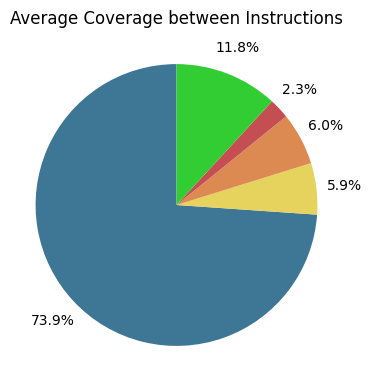

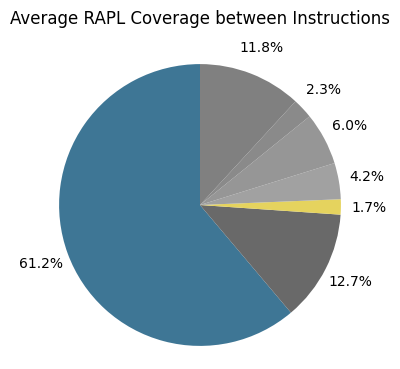

<Figure size 300x240 with 0 Axes>

<Figure size 300x120 with 0 Axes>

In [25]:
plot_pie_from_tuples(data_sensor, title="Average Coverage between Instructions", filename="pie_instructions.png")
plot_pie_from_tuples(data_rapl, title="Average RAPL Coverage between Instructions", filename="pie_rapl_instructions.png")

legend_only(data_sensor, filename="legend.png")
legend_only(data_rapl_legend, filename="legend_rapl.png")

In [20]:
# we really should just have a giant JSON about experiment statistics that is spit out by every benchmark next time, or a list, or a pickle, whatever isnt this bullshit.
segments = [17398106102790, 17408115632950, 17418125344082, 17428134473623, 17438142474785, 17448150626666, 17458160825127, 17468168994269, 17478177946304,17488185946880, 17498193747238]
df_partitions = []
prev = -1
for segment in segments:
    if (prev == -1):
        prev = segment
        continue 
    else: 
        df_partitions.append(rapl_teensy_merged[
            rapl_teensy_merged["timestamp"].between(
                prev,
                segment,
                inclusive="both"   # use "both" if you want inclusive
            )]
        )
        prev=segment
        

In [21]:
print(rapl_teensy_merged.columns)
mean_cpu = rapl_teensy_merged["cpu_total"].mean()
mean_power = rapl_teensy_merged["power"].mean()

print("Mean CPU total:", mean_cpu)
print("Mean Power:", mean_power)

def trapezoid (df, col= "cpu_total"): 

    # time differences (seconds)
    dt = df["timestamp"].diff() / 1e9
    df["timestamp_s"] = df["timestamp"] / 1e9

    # trapezoid: average power * time
    #energy_joules = ((df[col][:-1].values + df[col][1:].values) / 2 * dt[1:].values).sum() #naive trapezoid 
    energy_joules = np.trapz(df[col].values, x=df["timestamp_s"].values) #npz trapezoid

    # convert to kWh
    energy_kwh = energy_joules / 3_600_000

    print(col)
    print("Energy (J):", energy_joules)
    print("Energy (kWh):", energy_kwh)
    return energy_kwh

print(f"sum ={rapl_teensy_merged["energy"].sum()}??? probably wrong")


kwh1 = trapezoid(rapl_teensy_merged, col= "cpu_total")
kwh2 = trapezoid(rapl_teensy_merged, col= "power")
print(kwh1/kwh2) 



Index(['timestamp', 'energy_pkg', 'energy_dram', 'energy_psys', 'energy',
       'power', 'timestamp_1', 'timestamp_2', 'A_2', 'B_2', 'C_2', 'D_2',
       'H_2', 'I_2', 'J_2', 'K_2', 'Y_2', 'Z_2', 'O_2', 'P_2', 'Q_2', 'R_2',
       'U_2', 'V_2', 'timestamp_2_2', 'timestamp_diff', 'cpu_total',
       'abs_total', 'timestamp_s'],
      dtype='object')
Mean CPU total: 44.891884
Mean Power: 36.398968
sum =3857.184326171875??? probably wrong
cpu_total
Energy (J): 7094.810077435659
Energy (kWh): 0.0019707805770654606
power
Energy (J): 5751.970279177997
Energy (kWh): 0.0015977695219938882
1.2334573603620156


C:\Users\andyh\AppData\Local\Temp\ipykernel_25592\559216606.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy_joules = np.trapz(df[col].values, x=df["timestamp_s"].values) #npz trapezoid


In [22]:
for df_partition in df_partitions:
    kwh1 = trapezoid(df_partition, col="power")
    kwh2 = trapezoid(df_partition, col="cpu_total")
    print(kwh1/kwh2)

power
Energy (J): 475.1493237965543
Energy (kWh): 0.00013198592327682066
cpu_total
Energy (J): 574.4263046566375
Energy (kWh): 0.00015956286240462154
0.8271719451994354
power
Energy (J): 445.406307023763
Energy (kWh): 0.0001237239741732675
cpu_total
Energy (J): 541.8770442159821
Energy (kWh): 0.00015052140117110613
0.8219693227053043
power
Energy (J): 435.77235049011034
Energy (kWh): 0.00012104787513614176
cpu_total
Energy (J): 531.0167092129832
Energy (kWh): 0.0001475046414480509
0.8206377368726607
power
Energy (J): 423.15045815217223
Energy (kWh): 0.00011754179393115895
cpu_total
Energy (J): 517.9445992792243
Energy (kWh): 0.00014387349979978455
0.8169801533620229
power
Energy (J): 430.4799070303318
Energy (kWh): 0.00011957775195286994
cpu_total
Energy (J): 522.6604748721202
Energy (kWh): 0.0001451834652422556
0.8236320282984049
power
Energy (J): 653.3300835541932
Energy (kWh): 0.00018148057876505365
cpu_total
Energy (J): 784.8917547457404
Energy (kWh): 0.00021802548742937234
0.83238

C:\Users\andyh\AppData\Local\Temp\ipykernel_25592\559216606.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["timestamp_s"] = df["timestamp"] / 1e9
C:\Users\andyh\AppData\Local\Temp\ipykernel_25592\559216606.py:16: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  energy_joules = np.trapz(df[col].values, x=df["timestamp_s"].values) #npz trapezoid


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu

def cliffs_delta(x, y):
    """
    Compute Cliff's Delta effect size between two independent samples.
    δ ∈ [-1, 1]; magnitude interpreted as:
      |δ| < 0.147 → negligible
      |δ| < 0.33  → small
      |δ| < 0.474 → medium
      |δ| ≥ 0.474 → large
    """
    nx, ny = len(x), len(y)
    # count all pairwise comparisons
    gt = np.sum(x[:, None] > y)
    lt = np.sum(x[:, None] < y)
    delta = (gt - lt) / (nx * ny)
    return delta


def compare_column_means_nonparametric(df, time_col="timestamp_1",
                                       start1=6.52e13, start2=6.56e13, window=500,
                                       cols_range=range(ord('A'), ord('Z')+1)):
    """
    Compare A_2–Z_2 columns between two time windows using non-parametric tests.
    Reports direction, significance (Mann–Whitney U), and effect size (Cliff's Delta).

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing timestamp and sensor columns.
    time_col : str
        Timestamp column (nanoseconds).
    start1, start2 : float
        Center timestamps for the two regions.
    window : int
        Number of samples before and after each timestamp to include.
    cols_range : iterable
        Character range to define A–Z columns.

    Returns
    -------
    pd.DataFrame
        Per-column statistics: mean_before, mean_after, delta_mean,
        U_stat, p_value, direction, cliffs_delta, and effect_magnitude.
    """

    # Build expected column names: A_2, B_2, ..., Z_2
    cols = [f"{chr(c)}_2" for c in cols_range if f"{chr(c)}_2" in df.columns]

    # Find closest indices to given timestamps
    idx1 = (df[time_col] - start1).abs().idxmin()
    idx2 = (df[time_col] - start2).abs().idxmin()

    # Define window slices
    slice1 = df.iloc[max(0, idx1 - window): idx1 + window]
    slice2 = df.iloc[max(0, idx2 - window): idx2 + window]

    results = []

    for col in cols:
        x1 = slice1[col].dropna().to_numpy()
        x2 = slice2[col].dropna().to_numpy()

        if len(x1) < 10 or len(x2) < 10:
            continue  # skip if too few points

        # Non-parametric Mann–Whitney U test
        U, p = mannwhitneyu(x1, x2, alternative="two-sided")

        mean1, mean2 = x1.mean(), x2.mean()
        delta_mean = mean2 - mean1
        direction = "increase" if delta_mean > 0 else "decrease"

        # Cliff's Delta effect size
        delta = cliffs_delta(x1, x2)
        magnitude = (
            "negligible" if abs(delta) < 0.147 else
            "small" if abs(delta) < 0.33 else
            "medium" if abs(delta) < 0.474 else
            "large"
        )

        results.append({
            "column": col,
            "mean_before": mean1,
            "mean_after": mean2,
            "delta_mean": delta_mean,
            "abs_delta": abs(delta_mean),
            "U_stat": U,
            "p_value": p,
            "direction": direction,
            "cliffs_delta": delta,
            "effect_magnitude": magnitude
        })

    result_df = pd.DataFrame(results).sort_values(["p_value", "abs_delta"])

    print("Top statistically significant changes:")
    print(result_df.head(5))
    return result_df

print(compare_column_means_nonparametric(rapl_teensy_merged))

In [ ]:
import pandas as pd
import re

def rename_single_letter_cols(df: pd.DataFrame, suffix: str = "_2") -> pd.DataFrame:
    """
    Rename all single-letter column names (case-insensitive) by appending a suffix.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame.
    suffix : str, optional
        String to append to single-letter columns (default '_2').

    Returns
    -------
    pd.DataFrame
        New DataFrame with renamed columns.
    """
    rename_map = {
        col: f"{col}{suffix}" for col in df.columns
        if re.fullmatch(r"[A-Za-z]", str(col))
    }
    return df.rename(columns=rename_map)

In [ ]:
df_onlyTeensy = rename_single_letter_cols(df)
df_onlyTeensy["timestamp_1"] = df_onlyTeensy["timestamp"] 
print(compare_column_means_nonparametric(df_onlyTeensy))
df_onlyTeensy["cpu_total"] = (rapl_teensy_merged["Y_2"].astype("float32") + rapl_teensy_merged["Z_2"].astype("float32")).astype("float32")
df_onlyTeensy["abs_total"] = (rapl_teensy_merged["A_2"]+rapl_teensy_merged["B_2"]+rapl_teensy_merged["C_2"]+rapl_teensy_merged["D_2"]+rapl_teensy_merged["H_2"]+rapl_teensy_merged["I_2"]+rapl_teensy_merged["J_2"]+rapl_teensy_merged["K_2"]+rapl_teensy_merged["Y_2"]+rapl_teensy_merged["Z_2"]+rapl_teensy_merged["O_2"]+rapl_teensy_merged["P_2"]+rapl_teensy_merged["Q_2"]+rapl_teensy_merged["R_2"]+rapl_teensy_merged["U_2"]+rapl_teensy_merged["V_2"])

plot_cpu_vs_energy(df_onlyTeensy, time_col="timestamp", cpu_col="cpu_total", energy_col="abs_total", sample_factor=1000)


here we identify P, Q, R, A and C as the main contributor to this increase. 

We identified using time stamps that the benchmark that cause this to occur is 549.fotonik3d_r refrate base

In [ ]:
import matplotlib.pyplot as plt

def plot_cpu_vs_rapl(df, cpu_col="cpu_total", rapl_col="power"):
    """
    Scatter plot of RAPL energy vs CPU total power.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing cpu_total and energy columns.
    cpu_col : str, default 'cpu_total'
        Column name for CPU total (x-axis).
    rapl_col : str, default 'energy'
        Column name for RAPL energy (y-axis).
    """
    df = df.iloc[::100, :]
    plt.figure(figsize=(7, 5))
    plt.scatter(df[cpu_col], df[rapl_col], s=5, alpha=0.6, color="tab:blue")

    plt.xlabel("CPU Total Power (W)")
    plt.ylabel("RAPL Power (W)")
    plt.title("RAPL Power vs CPU Total Power")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()
plot_cpu_vs_rapl(rapl_teensy_running_average)
plot_cpu_vs_rapl(rapl_teensy_running_average,cpu_col="abs_total")

In [ ]:
print(rapl_teensy_merged.columns)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def heatmap_2d_correlation(df, col_x, col_y, bins=80, cmap="plasma"):
    """
    Create a 2D heatmap (binned density) between two numeric columns.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame
    col_x : str
        First column name
    col_y : str
        Second column name
    bins : int
        Number of bins along both axes (default 80)
    cmap : str
        Heatmap color scheme
        
    Returns
    -------
    None
    """

    # Drop NaN
    data = df[[col_x, col_y]].dropna()

    x = data[col_x].astype(np.float32).to_numpy()
    y = data[col_y].astype(np.float32).to_numpy()

    # 2D histogram
    heatmap, xedges, yedges = np.histogram2d(x, y, bins=bins)

    #ceiling
    ceiling = np.percentile(heatmap, 97)   # keep bottom % dynamic
    heatmap_clipped = np.clip(heatmap, 0, ceiling)

    # Log scale (add epsilon to prevent log(0))
    heatmap_log = np.log1p(heatmap)

    

    # Plot
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        heatmap_clipped.T,
        cmap=cmap,
        cbar=True,
        xticklabels=False,
        yticklabels=False,
        square=True
    )

    plt.xlabel(col_x)
    plt.ylabel(col_y)
    plt.title(f"2D Heatmap: {col_x} vs {col_y}")
    plt.tight_layout()
    plt.show()
heatmap_2d_correlation(rapl_teensy_running_average, "cpu_total_bw", "power_bw", bins=60)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def show_raw_distributions(
        df: pd.DataFrame,
        col1: str,
        col2: str,
        step_size: float,
        overlay=True
    ):
    """
    Show the distribution of raw observations between two numeric columns
    using user-defined bin step size.

    Parameters
    ----------
    df : pd.DataFrame
        Source data
    col1 : str
        First column name
    col2 : str
        Second column name
    step_size : float
        Histogram bin width
    overlay : bool
        If True → overlay histograms; otherwise → side-by-side subplots

    Returns
    -------
    (counts1, bins), (counts2, bins)
    """

    # Extract values
    vals1 = df[col1].dropna()
    vals2 = df[col2].dropna()

    # Determine global bin range
    minv = min(vals1.min(), vals2.min())
    maxv = max(vals1.max(), vals2.max())

    bins = np.arange(minv, maxv + step_size, step_size)

    counts1, edges1 = np.histogram(vals1, bins=bins)
    counts2, edges2 = np.histogram(vals2, bins=bins)

    # Plot
    if overlay:
        plt.figure(figsize=(8,4))
        plt.hist(vals1, bins=bins, alpha=0.5, label=col1)
        plt.hist(vals2, bins=bins, alpha=0.5, label=col2)
        plt.xlabel("Value")
        plt.ylabel("Count")
        plt.title("Raw Value Distributions")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        fig, axs = plt.subplots(1, 2, figsize=(10,4), sharey=True)
        axs[0].hist(vals1, bins=bins)
        axs[0].set_title(col1)
        axs[1].hist(vals2, bins=bins)
        axs[1].set_title(col2)
        for ax in axs:
            ax.set_xlabel("Value")
            ax.set_ylabel("Count")
            ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    return (counts1, edges1), (counts2, edges2)

show_raw_distributions(rapl_teensy_merged, col1="cpu_total", col2="power", step_size=0.1)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_time_value_heatmap(
        df: pd.DataFrame,
        time_col: str,
        value_col: str,
        time_step: float,
        value_step: float,
        cmap="viridis"
    ):
    """
    Plots a 2D heatmap of (time vs value) binned by given step sizes.

    Parameters
    ----------
    df : pd.DataFrame
        Source data
    time_col : str
        Timestamp column
    value_col : str
        Value column
    time_step : float
        Bin width along time axis
    value_step : float
        Bin width along value axis
    cmap : str
        Matplotlib colormap

    Returns
    -------
    H, xedges, yedges
        2D histogram counts and edges
    """

    t = df[time_col].values
    v = df[value_col].values

    # Compute bins
    t_min, t_max = t.min(), t.max()
    v_min, v_max = v.min(), v.max()

    t_bins = np.arange(t_min, t_max + time_step, time_step)
    v_bins = np.arange(v_min, v_max + value_step, value_step)

    # 2D histogram
    H, xedges, yedges = np.histogram2d(t, v, bins=[t_bins, v_bins])

    plt.figure(figsize=(10,4))
    plt.pcolormesh(xedges, yedges, H.T, cmap=cmap, shading='auto')
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.title(f"Heatmap of {value_col} over time")
    plt.colorbar(label="Count")
    plt.tight_layout()
    plt.show()

    return H, xedges, yedges

H, xedges, yedges = plot_time_value_heatmap(
    rapl_teensy_merged,
    time_col="timestamp",
    value_col="cpu_total",
    time_step=10_000_000_000,
    value_step=1
)

H, xedges, yedges = plot_time_value_heatmap(
    rapl_teensy_merged,
    time_col="timestamp",
    value_col="energy",
    time_step=10_000_000_000,
    value_step=1
)

In [ ]:
import scipy.stats as stats
import numpy as np

def nonparametric_correlation(df, col_x="cpu_total", col_y="power"):
    """
    Compute non-parametric correlation between two columns (Spearman and Kendall).

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing both columns.
    col_x : str
        First variable (e.g. CPU total power).
    col_y : str
        Second variable (e.g. RAPL or measured power).

    Returns
    -------
    dict
        Spearman and Kendall correlation results.
    """
    # Drop missing values
    data = df[[col_x, col_y]].dropna()

    x = data[col_x].to_numpy()
    y = data[col_y].to_numpy()

    # Spearman rank correlation (monotonic relationship)
    spearman_rho, spearman_p = stats.spearmanr(x, y)

    # Kendall Tau correlation (ordinal consistency)
    kendall_tau, kendall_p = stats.kendalltau(x, y)

    results = {
        "spearman_rho": spearman_rho,
        "spearman_p": spearman_p,
        "kendall_tau": kendall_tau,
        "kendall_p": kendall_p,
        "n": len(data)
    }

    print(f"Spearman ρ = {spearman_rho:.4f} (p = {spearman_p:.3e})")
    print(f"Kendall τ = {kendall_tau:.4f} (p = {kendall_p:.3e})")
    print(f"Samples used: {len(data)}")

    return results

print(nonparametric_correlation(rapl_teensy_merged))


In [ ]:
print(nonparametric_correlation(rapl_teensy_merged, col_x="A_2", col_y="C_2"))
print(nonparametric_correlation(rapl_teensy_merged, col_x="Y_2", col_y="Z_2")) #sanity test here, Y and Z is both CPU 
print(nonparametric_correlation(rapl_teensy_merged, col_x="R_2", col_y="P_2"))
print(nonparametric_correlation(rapl_teensy_merged, col_x="Q_2", col_y="P_2"))




In [ ]:
# CHOICE 1
def sum_y_z_with_timestamp(df: pd.DataFrame, col_y: str = "Y", col_z: str = "Z") -> pd.DataFrame:
    """
    Return a new DataFrame with timestamp and the sum of col_y and col_z.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame with timestamp and sensor columns.
        col_y (str): Name of first column to sum (default: "Y")
        col_z (str): Name of second column to sum (default: "Z")
    
    Returns:
        pd.DataFrame: DataFrame with 'timestamp' and a new column 'Y_plus_Z'
    """
    return pd.DataFrame({
        "timestamp": df["timestamp"],
        f"{col_y}_plus_{col_z}": df[col_y] + df[col_z]
    })

result = sum_y_z_with_timestamp(corrected_df)
print(result)

In [ ]:
import pandas as pd
import numpy as np

def analyze_variance(df, col):
    """
    Compute descriptive variance statistics for a numeric column.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame.
    col : str
        Name of the numeric column to analyze.

    Returns
    -------
    dict
        Dictionary containing mean, variance, std, coefficient of variation, and IQR.
    """
    x = df[col].dropna()

    stats = {
        "count": len(x),
        "mean": float(np.mean(x)),
        "variance": float(np.var(x, ddof=1)),  # sample variance
        "std_dev": float(np.std(x, ddof=1)),
        "coefficient_of_variation": float(np.std(x, ddof=1) / np.mean(x)) if np.mean(x) != 0 else np.nan,
        "min": float(np.min(x)),
        "max": float(np.max(x)),
        "iqr": float(np.percentile(x, 75) - np.percentile(x, 25))
    }

    print(f"--- Variance Analysis for '{col}' ---")
    for k, v in stats.items():
        print(f"{k:>25}: {v}")
    return stats
print(analyze_variance(rapl_teensy_merged, "power"))
print(analyze_variance(rapl_teensy_merged, "cpu_total"))


In [ ]:
#check normality at points
import numpy as np
import pandas as pd
from scipy.stats import shapiro, normaltest, anderson

def test_local_normality_at_points(
    df: pd.DataFrame,
    timestamp_col: str,
    value_col: str,
    points: list,
    N: int = 20,
    alpha: float = 0.05,
    method: str = "shapiro"
):
    """
    For each timestamp in `points`, find the nearest timestamp in the DataFrame,
    extract a window of N samples centered on it, and test if that segment is normally distributed.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with timestamp and value columns.
    timestamp_col : str
        Name of the timestamp column (must be integer-like, sorted ascending).
    value_col : str
        Name of the value column to test.
    points : list[float or int]
        List of timestamps (e.g., 1.03e13) where normality should be checked.
    N : int, optional
        Number of samples in the local window (default 20).
    alpha : float, optional
        Significance level for normality tests (default 0.05).
    method : {'shapiro', 'dagostino', 'anderson'}
        Statistical test to use for normality.

    Returns
    -------
    pd.DataFrame
        Columns: ['target_timestamp', 'nearest_timestamp', 'index', 'p_value', 'is_normal']
    """
    timestamps = df[timestamp_col].to_numpy(dtype=np.uint64)
    values = df[value_col].to_numpy(dtype=float)
    half = N // 2

    results = []
    for p in points:
        # Convert to uint64-compatible int
        p_int = np.uint64(round(p))
        # Find nearest index
        idx = np.abs(timestamps - p_int).argmin()
        start = max(0, idx - half)
        end = min(len(df), idx + half + 1)
        window = values[start:end]

        if len(window) < 3:
            results.append((p, timestamps[idx], idx, np.nan, np.nan))
            continue

        if method == "shapiro":
            stat, pval = shapiro(window)
            is_norm = pval > alpha
        elif method == "dagostino":
            stat, pval = normaltest(window)
            is_norm = pval > alpha
        elif method == "anderson":
            res = anderson(window)
            idx_crit = np.searchsorted(res.significance_level, alpha * 100, side="right") - 1
            idx_crit = np.clip(idx_crit, 0, len(res.critical_values) - 1)
            is_norm = res.statistic < res.critical_values[idx_crit]
            pval = np.nan
        else:
            raise ValueError(f"Unknown method: {method}")

        results.append((p, timestamps[idx], idx, pval, is_norm))

    return pd.DataFrame(results, columns=[
        "target_timestamp", "nearest_timestamp", "index", "p_value", "is_normal"
    ])

points = [6.52e13, 6.58e13]

res = test_local_normality_at_points(rapl_teensy_merged, "timestamp", "power", points, N=2000, method="shapiro")
print(res)

res = test_local_normality_at_points(rapl_teensy_merged, "timestamp", "cpu_total", points, N=2000, method="shapiro")
print(res)


EVERYTHING BEYOND THIS POINT DEPRECATED ------> OCTOBER 21

In [ ]:
#CHOICE 2
def stack_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Return a new DataFrame with timestamp and the sum of col_y and col_z.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame with timestamp and sensor columns.
        col_y (str): Name of first column to sum (default: "Y")
        col_z (str): Name of second column to sum (default: "Z")
    
    Returns:
        pd.DataFrame: DataFrame with 'timestamp' and a new column 'Y_plus_Z'
    """
    return pd.DataFrame({
        "timestamp": df["timestamp"],
        #f"SATA": df["U"] + df["V"],
        f"mobo": df["H"] + df["I"] + df["J"] + df["K"]+ df ["O"] + df["P"] + df["Q"] + df["R"],
        f"cpu": df["Z"] + df["Y"]
    })

result = stack_columns(corrected_df)
print(result)

In [ ]:
def convert_timestamp_to_seconds(df: pd.DataFrame, time_col: str = "timestamp",
                                 clock_hz: int = 24_000_000,
                                 new_col: str = "time_seconds") -> pd.DataFrame:
    """
    Convert hardware timestamp ticks to seconds using the given clock speed.
    
    Parameters:
        df (pd.DataFrame): DataFrame with timestamp column in ticks.
        time_col (str): Name of the timestamp column.
        clock_hz (int): Clock frequency in Hz (default: 24 MHz).
        new_col (str): Name of the new column containing time in seconds.
    
    Returns:
        pd.DataFrame: Copy of df with an added 'time_seconds' column.
    """
    result_df = df.copy()
    result_df[new_col] = result_df[time_col] / clock_hz
    return result_df

df_seconds = convert_timestamp_to_seconds(result)
print(df_seconds.head(10))
print(df_seconds.tail(5))

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_three_sensors(df: pd.DataFrame,
                       time_col: str = "time_seconds",
                       sensors: list = ["Y_plus_Z"],
                       dpi: int = 200):
    """
    Plot three sensor columns vs. timestamp on the same figure.

    Parameters:
        df (pd.DataFrame): DataFrame containing timestamp and sensor data.
        time_col (str): Column name for timestamp (default: "timestamp").
        sensors (list): List of three column names to plot.
        dpi (int): Figure resolution in DPI (default: 200).
    """
    if len(sensors) != 2:
        print("Please provide exactly three sensor column names.")

    plt.figure(figsize=(10, 5), dpi=dpi)
    
    for sensor in sensors:
        plt.plot(df[time_col], df[sensor],
                 marker='o', markersize=3, linewidth=0.8, label=sensor)

    plt.xlabel("Timestamp")
    plt.ylabel("Sensor Values")
    plt.title("Sensor Readings vs Timestamp")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_three_sensors(df_seconds, time_col="time_seconds")

In [ ]:
import pandas as pd

def convert_time_seconds_to_datetime(df: pd.DataFrame, start_time_str: str) -> pd.DataFrame:
    """
    Convert a column 'time_seconds' (relative seconds) into absolute datetimes
    in the format 'YYYY-MM-DD HH:MM:SS.sss', aligning the first value of 'time_seconds'
    to the provided starting timestamp.

    Example output: 2025-09-30 23:12:32.734

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing a 'time_seconds' column.
    start_time_str : str
        Starting time string, e.g. "2025-09-30 23:12:32.734" or "09/18/2025 16:46:04".

    Returns
    -------
    pd.DataFrame
        DataFrame with an added 'datetime' column (string format) and set as index.
    """
    if "time_seconds" not in df.columns:
        raise ValueError("DataFrame must contain a 'time_seconds' column")

    # Try multiple possible formats for safety
    try:
        start_dt = pd.to_datetime(start_time_str, format="%Y-%m-%d %H:%M:%S.%f")
    except ValueError:
        start_dt = pd.to_datetime(start_time_str, format="%m/%d/%Y %H:%M:%S")

    df = df.copy()
    first_val = df["time_seconds"].iloc[0]
    df["time_seconds_adj"] = df["time_seconds"] - first_val

    # Create datetime column
    df["datetime"] = start_dt + pd.to_timedelta(df["time_seconds_adj"], unit="s")

    # Format datetime to desired string format with millisecond precision
    df["datetime"] = df["datetime"].dt.strftime("%Y-%m-%d %H:%M:%S.%f").str[:-3]

    # Set datetime as index
    #df = df.set_index("datetime")

    return df

df_with_dt = convert_time_seconds_to_datetime(df_seconds, "2025-09-30 23:12:45.000")
print(df_with_dt.head(5))
print(df_with_dt.tail(5))
print(df_with_dt.shape)
print(df_with_dt.dropna().shape)
df_with_dt.rename(columns={"timestamp": "timeold"}, inplace=True)
df_with_dt.rename(columns={"datetime": "timestamp"}, inplace=True)
print(df_with_dt.head(5))



In [ ]:
#ONLY USE THIS IF YOU ARE USING LOG FROM HARDWARE MONITOR!!!!!
import os
import pandas as pd

import os
import glob
import pandas as pd

def read_open_hardware_monitor_log(folder: str) -> pd.DataFrame:
    """
    Searches for a CSV file in `folder` that contains 'OpenHardwareMonitorLog' in its name,
    loads it into a pandas DataFrame, and returns a cleaned version.
    
    - Automatically finds the first matching file.
    - Strips whitespace from column names.
    - Parses 'Time' column to datetime and sets it as index.
    - Converts other columns to numeric where possible.
    
    Parameters
    ----------
    folder : str
        Path to the folder containing the OpenHardwareMonitor log CSV.
    
    Returns
    -------
    pd.DataFrame
        Cleaned DataFrame with DateTimeIndex.
    
    Raises
    ------
    FileNotFoundError
        If no matching file is found in the folder.
    """
    # Find matching files
    pattern = os.path.join(folder, "*OpenHardwareMonitorLog*.csv")
    matching_files = glob.glob(pattern)

    if not matching_files:
        raise FileNotFoundError(f"No CSV file containing 'OpenHardwareMonitorLog' found in {folder}")

    # Pick the first match (or you could pick the latest by modified time)
    file_path = matching_files[0]

    # Load CSV
    df = pd.read_csv(file_path, encoding="utf-8", low_memory=False)

    # Clean column names
    df.columns = df.columns.str.strip()

    # Parse 'Time' column if present and set as index
    if "Time" in df.columns:
        df["Time"] = pd.to_datetime(df["Time"], errors="coerce")
        df = df.set_index("Time")

    # Convert other columns to numeric
    df = df.apply(pd.to_numeric, errors="ignore")

    return df

df_OHML = read_open_hardware_monitor_log("./trace/trace-e2")
print(df_OHML.head(10))

In [ ]:
import pandas as pd

import pandas as pd

def clean_open_hardware_monitor_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clean and aggregate an OpenHardwareMonitor DataFrame:
    
    1. Drop row 0 (extra info)
    2. Convert datetime-like columns to datetime
    3. Convert all other columns to float
    4. Aggregate CPU load and CPU power into new columns
    
    Parameters
    ----------
    df : pd.DataFrame
        Raw DataFrame from read_open_hardware_monitor_log()

    Returns
    -------
    pd.DataFrame
        Cleaned DataFrame with datetime-aware index and numeric columns
    """
    # 1. Drop row 0
    df_clean = df.iloc[1:].copy()

    # 2. Convert datetime-like columns first
    for col in df_clean.columns:
        try:
            # Try parsing; only replace if most values convert successfully
            converted = pd.to_datetime(df_clean[col], format="%m/%d/%Y %H:%M:%S", errors="coerce")
            if converted.notna().mean() > 0.8:  # at least 80% valid datetimes
                df_clean[col] = converted
        except Exception:
            pass

    # 3. Convert remaining columns to float
    for col in df_clean.columns:
        if not pd.api.types.is_datetime64_any_dtype(df_clean[col]):
            df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

    # If we have a "Time" column as datetime, make it the index
    if "Time" in df_clean.columns and pd.api.types.is_datetime64_any_dtype(df_clean["Time"]):
        df_clean = df_clean.set_index("Time")

    # 4. Compute cpuload and cpupower
    load_cols = [c for c in df_clean.columns if c.startswith("/intelcpu/0/load/") and any(c.endswith(f"/{i}") for i in range(1, 7))]
    power_cols = [c for c in df_clean.columns if c.startswith("/intelcpu/0/power/") and any(c.endswith(f"/{i}") for i in range(1, 3))]

    if load_cols:
        df_clean["cpuload"] = df_clean[load_cols].sum(axis=1, skipna=True)
    if power_cols:
        df_clean["cpupower"] = df_clean[power_cols].sum(axis=1, skipna=True)

    return df_clean

df_cleaned = clean_open_hardware_monitor_df(df_OHML)
print(df_cleaned.head(19))

In [ ]:
#for turbostat only LOAD TURBO STAT
import os
import pandas as pd

def load_turbostat_log(folder_path: str) -> pd.DataFrame:
    """
    Search for a CSV file containing 'turbostat_log' in its name within the given folder path,
    load it into a pandas DataFrame, and return it.

    Parameters
    ----------
    folder_path : str
        Path to the folder where the CSV file is located.

    Returns
    -------
    pd.DataFrame
        DataFrame containing the contents of the matched CSV file.

    Raises
    ------
    FileNotFoundError
        If no matching file is found.
    """
    # Ensure folder exists
    if not os.path.isdir(folder_path):
        raise FileNotFoundError(f"The folder path '{folder_path}' does not exist.")

    # Search for matching file
    for file_name in os.listdir(folder_path):
        if "turbostat_log" in file_name and file_name.endswith(".csv"):
            file_path = os.path.join(folder_path, file_name)
            print(f"✅ Found file: {file_path}")
            return pd.read_csv(file_path)

    # If no file found
    raise FileNotFoundError(f"No CSV file containing 'turbostat_log' found in {folder_path}.")

df = load_turbostat_log("C:/Users/andyh/Downloads/serialreceive/trace/turbostat")
print(df.head())
df_rawturbostat = df

df_rawturbostat = df_rawturbostat.drop('gfx_watt', axis=1)
df_rawturbostat = df_rawturbostat.drop('pkg_j', axis=1)
print(df_rawturbostat.head())





In [ ]:
import os
import pandas as pd

def load_cpu_usage_log(folder_path: str) -> pd.DataFrame:
    """
    Searches a directory (recursively) for a CSV file containing 'cpu_usage_log'
    in its name and returns it as a pandas DataFrame.

    Args:
        folder_path (str): The path to the directory to search.

    Returns:
        pd.DataFrame: The loaded DataFrame.

    Raises:
        FileNotFoundError: If no matching CSV file is found.
    """
    # Walk through directory and subdirectories
    for root, _, files in os.walk(folder_path):
        for file in files:
            if "cpu_usage_log" in file and file.endswith(".csv"):
                file_path = os.path.join(root, file)
                print(f"✅ Found file: {file_path}")
                return pd.read_csv(file_path)

    raise FileNotFoundError(f"No file containing 'cpu_usage_log' found in {folder_path}")

df = load_cpu_usage_log("C:/Users/andyh/Downloads/serialreceive/trace/turbostat")
print(df.head())

#might need some cleaning 
df = df.dropna()
print(df.head(5))

df_raw_cpuusage = df



In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_combined_metrics(df1, df2, df3):
    """
    Plot Y_plus_Z (df1), pkg_watt (df2), and cpu_usage_percent (df3)
    against their common 'timestamp' column.
    
    - Y_plus_Z and pkg_watt share the left y-axis.
    - cpu_usage_percent uses a secondary y-axis.
    - Lines are thin for clarity.
    """

    # --- Convert timestamps to datetime for consistent x-axis ---
    df1 = df1.copy()
    df2 = df2.copy()
    df3 = df3.copy()

    for df in [df1, df2, df3]:
        if not pd.api.types.is_datetime64_any_dtype(df["timestamp"]):
            df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
        df.dropna(subset=["timestamp"], inplace=True)

    # --- Create the figure and axes ---
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Plot Y_plus_Z (df1) and pkg_watt (df2) on the same axis
    ax1.plot(df1["timestamp"], df1["Y_plus_Z"], label="Y + Z", color="tab:blue", linewidth=0.8)
    ax1.plot(df2["timestamp"], df2["pkg_watt"], label="Package Power (W)", color="tab:orange", linewidth=0.8)

    ax1.set_xlabel("Time")
    ax1.set_ylabel("Power / Sensor (W)", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    # --- Secondary axis for CPU usage ---
    ax2 = ax1.twinx()
    ax2.plot(df3["timestamp"], df3["cpu_usage_percent"], label="CPU Usage (%)", color="tab:red", linewidth=0.8)
    ax2.set_ylabel("CPU Usage (%)", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    # --- Titles, grid, and legends ---
    fig.suptitle("Sensor (Y+Z), Package Power, and CPU Usage Over Time", fontsize=12)
    fig.autofmt_xdate(rotation=30)
    ax1.grid(True, linestyle="--", alpha=0.4)

    # Combine legends from both axes
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc="upper left", fontsize=8)

    plt.tight_layout()
    plt.show()

plot_combined_metrics(df_with_dt, df_rawturbostat, df_raw_cpuusage)


In [ ]:
#old
import matplotlib.pyplot as plt

def plot_cpu_metrics(df: pd.DataFrame):
    """
    Plot cpuload and cpupower over time using matplotlib.
    
    - cpuload is shown on the left y-axis
    - cpupower is shown on the right y-axis
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing at least 'cpuload' and 'cpupower' columns,
        with a DateTimeIndex or a 'Time' column.
    """
    if df.empty:
        print("DataFrame is empty — nothing to plot.")
        return
    
    # Ensure we have a datetime index
    if "Time" in df.columns and not isinstance(df.index, pd.DatetimeIndex):
        df = df.set_index("Time")

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Left y-axis: CPU Load
    ax1.plot(df.index, df["cpuload"], label="CPU Load (%)", color="tab:blue")
    ax1.set_xlabel("Time")
    ax1.set_ylabel("CPU Load (%)", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    # Right y-axis: CPU Power
    ax2 = ax1.twinx()
    ax2.plot(df.index, df["cpupower"], label="CPU Power (W)", color="tab:red")
    ax2.set_ylabel("CPU Power (W)", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    # Title and grid
    plt.title("CPU Load and Power Over Time")
    ax1.grid(True, which="both", linestyle="--", alpha=0.5)

    # Show
    fig.tight_layout()
    plt.show()

plot_cpu_metrics(df_cleaned)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_combined_metrics_relative(df_with_dt: pd.DataFrame, df_cleaned: pd.DataFrame):
    """
    Plot mobo, cpu, cpupower (shared left y-axis) and cpuload (right y-axis)
    over a shared timeline, using earliest timestamp as time zero.

    - X-axis shows seconds since earliest timestamp
    - Title shows the starting timestamp (human-readable)
    - Covers full range from earliest of both to latest of both
    """
    # --- Ensure datetime index for df_with_dt
    if "datetime" in df_with_dt.columns:
        df_with_dt = df_with_dt.set_index("datetime")
    df_with_dt.index = pd.to_datetime(df_with_dt.index)

    # --- Ensure datetime index for df_cleaned
    if "Time" in df_cleaned.columns:
        df_cleaned = df_cleaned.set_index("Time")
    df_cleaned.index = pd.to_datetime(df_cleaned.index)

    # --- Determine global start and end time
    global_start = min(df_with_dt.index.min(), df_cleaned.index.min())
    global_end   = max(df_with_dt.index.max(), df_cleaned.index.max())

    # --- Compute relative seconds since global_start
    df_with_dt_rel = df_with_dt.copy()
    df_with_dt_rel["rel_sec"] = (df_with_dt_rel.index - global_start).total_seconds()

    df_cleaned_rel = df_cleaned.copy()
    df_cleaned_rel["rel_sec"] = (df_cleaned_rel.index - global_start).total_seconds()

    # --- Debug info
    print(f"Global start time: {global_start}, end time: {global_end}")
    print(df_with_dt_rel[["rel_sec", "mobo", "cpu"]].head())
    print(df_cleaned_rel[["rel_sec", "cpuload", "cpupower"]].head())

    # --- Plotting
    fig, ax1 = plt.subplots(figsize=(14, 7))

    # Left y-axis: mobo, cpu, cpupower
    ax1.plot(df_with_dt_rel["rel_sec"], df_with_dt_rel["mobo"], label="Mobo", color="tab:blue")
    ax1.plot(df_with_dt_rel["rel_sec"], df_with_dt_rel["cpu"], label="CPU", color="tab:green")
    ax1.plot(df_cleaned_rel["rel_sec"], df_cleaned_rel["cpupower"], label="CPU Power (W)", color="tab:red")
    ax1.set_xlabel("Time (seconds since start)")
    ax1.set_ylabel("Mobo / CPU / Power (units)")
    ax1.tick_params(axis="y", labelcolor="black")
    ax1.grid(True, linestyle="--", alpha=0.4)

    # Right y-axis: cpuload (separate scale)
    ax2 = ax1.twinx()
    #ax2.plot(df_cleaned_rel["rel_sec"], df_cleaned_rel["cpuload"], label="CPU Load (%)", color="tab:orange", alpha=0.7)
    ax2.set_ylabel("CPU Load (%)")
    ax2.tick_params(axis="y", labelcolor="tab:orange")

    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

    plt.title(f"CPU & Mobo Metrics — Start: {global_start.strftime('%m/%d/%Y %H:%M:%S')}")
    plt.tight_layout()
    plt.show()

# Example usage: 
df_cleaned = df_cleaned.rename(columns={"Unnamed: 0": "Time"})
plot_combined_metrics_relative(df_with_dt, df_cleaned)

In [ ]:
print(df_with_dt.head(5))
print(df_cleaned.head(5))

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_combined_metrics_relative(df_with_dt: pd.DataFrame, df_cleaned: pd.DataFrame):
    """
    Plot mobo, cpu, cpupower (shared left y-axis) and cpuload (right y-axis)
    over a shared timeline, using earliest timestamp as time zero.

    - X-axis shows seconds since earliest timestamp
    - Title shows the starting timestamp (human-readable)
    - Covers full range from earliest of both to latest of both
    """
    # --- Ensure datetime index for df_with_dt
    if "datetime" in df_with_dt.columns:
        df_with_dt = df_with_dt.set_index("datetime")
    df_with_dt.index = pd.to_datetime(df_with_dt.index)

    # --- Ensure datetime index for df_cleaned
    if "Time" in df_cleaned.columns:
        df_cleaned = df_cleaned.set_index("Time")
    df_cleaned.index = pd.to_datetime(df_cleaned.index)

    # --- Determine global start and end time
    global_start = min(df_with_dt.index.min(), df_cleaned.index.min())
    global_end   = max(df_with_dt.index.max(), df_cleaned.index.max())

    # --- Compute relative seconds since global_start
    df_with_dt_rel = df_with_dt.copy()
    df_with_dt_rel["rel_sec"] = (df_with_dt_rel.index - global_start).total_seconds()

    df_cleaned_rel = df_cleaned.copy()
    df_cleaned_rel["rel_sec"] = (df_cleaned_rel.index - global_start).total_seconds()

    # --- Debug info
    print(f"Global start time: {global_start}, end time: {global_end}")
    print(df_with_dt_rel[["rel_sec", "mobo", "cpu"]].head())
    print(df_cleaned_rel[["rel_sec", "cpuload", "cpupower"]].head())

    # --- Plotting
    fig, ax1 = plt.subplots(figsize=(14, 7))

    # Left y-axis: mobo, cpu, cpupower
    ax1.plot(df_with_dt_rel["rel_sec"], df_with_dt_rel["mobo"], label="Mobo", color="tab:blue", linewidth=0.3)
    ax1.plot(df_with_dt_rel["rel_sec"], df_with_dt_rel["cpu"], label="CPU", color="tab:green", linewidth=0.3)
    ax1.plot(df_cleaned_rel["rel_sec"], df_cleaned_rel["cpupower"], label="CPU Power (W)", color="tab:red", linewidth=0.3)
    ax1.set_xlabel("Time (seconds since start)")
    ax1.set_ylabel("Mobo / CPU / Power (units)")
    ax1.tick_params(axis="y", labelcolor="black")
    ax1.grid(True, linestyle="--", alpha=0.4)

    # Right y-axis: cpuload (separate scale)
    ax2 = ax1.twinx()
    ax2.plot(df_cleaned_rel["rel_sec"], df_cleaned_rel["cpuload"], label="CPU Load (%)",
             color="tab:orange", alpha=0.7, linewidth=0.3)
    ax2.set_ylabel("CPU Load (%)")
    ax2.tick_params(axis="y", labelcolor="tab:orange")

    # Combine legends from both axes
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

    plt.title(f"CPU & Mobo Metrics — Start: {global_start.strftime('%m/%d/%Y %H:%M:%S')}")
    plt.tight_layout()
    plt.show()

# Example usage: 
df_cleaned = df_cleaned.rename(columns={"Unnamed: 0": "Time"})
plot_combined_metrics_relative(df_with_dt, df_cleaned)
